# Corpus-Scale Analysis with TEA Nets (Batch Extraction)

The other guides extract a TEA network from **one** text at a time. This notebook shows the **corpus workflow**: how to run TEA extraction over a **whole dataset of documents** with `teanets.batch_extract`, then analyse the result — *who* (which actors) is described as doing *what* (which actions), in active vs passive voice, across the corpus.

All data here is **small, synthetic and neutral** (a fictional town/newsroom), so the notebook is fully reproducible and safe to share. To analyse your own corpus, replace the demo CSV with your own (one document per row, a `text` column).

**Related guides**
- New to the library? Start with the **[Starting Guide](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Starting%20Guide.ipynb)** (install + basics).
- Network metrics (centrality, filtering, exports): **[Analyzing TEA](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Analyzing%20TEA.ipynb)**.
- Grouping actors into categories: **[Actor Categorization](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Actor_Categorization_Tutorial.ipynb)**.

**What you'll do**
1. Build a small demo corpus (a CSV of documents).
2. Run **batch SVO extraction** over it (CPU or GPU).
3. Keep only **genuine** Agent→Event edges (handling passive voice).
4. Normalise verbs and actors, then **categorise** the actors.
5. Look at **frequencies**, the **actor→verb→object network**, and **active vs passive** voice.

## Setup

Full install instructions live in the **[Starting Guide](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Starting%20Guide.ipynb)**. On **Google Colab**, uncomment the two lines in the cell below (first run only, ~3–4 min), then do *Runtime → Restart session* and re-run.

In [1]:
# ── Setup ────────────────────────────────────
# ▶ ON GOOGLE COLAB: uncomment the two lines below (first run only, ~3-4 min),
#   then do "Runtime > Restart session" and re-run from here.
# !pip install -q --retries 10 --timeout 120 git+https://github.com/MassimoStel/TEA_Networks.git
# !python -m spacy download en_core_web_trf

# ▶ LOCAL CLONE: make `import teanets` work when running from Docs & Guides/.
import sys, os
_repo_root = os.path.abspath("..")
if os.path.isdir(os.path.join(_repo_root, "teanets")):
    sys.path.insert(0, _repo_root)

import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import re
import teanets as tea
from teanets import batch_extract
print(f"teanets {tea.__version__} ready")

teanets 0.3.1 ready


## 1. Build a demo corpus

`batch_extract` reads a **CSV with one document per row**; the default text column is named `text`. Here we write a tiny neutral corpus to `demo_corpus.csv`. To analyse real data, just point the extractor at your own CSV instead.

In [2]:
corpus = [
    "The mayor praised the volunteers for their hard work.",
    "The journalist criticized the new policy.",
    "The teacher helped the students with their projects.",
    "The volunteers were praised by the mayor at the ceremony.",
    "The annual report was criticized harshly.",
    "The director blamed the manager for the delay.",
    "The mayor thanked the firefighters and supported their request.",
    "The professor praised the researcher. She later thanked the whole team.",
    "The students were helped by the teacher after class.",
    "The editor criticized the reporter for the mistake.",
    "The neighbor helped the elderly resident.",
    "The coach praised the players and the captain.",
    "The manager was blamed by the director.",
    "The principal warned the students about the deadline.",
    "The mayor supported the local farmers.",
    "The teacher praised the student who fixed the projector.",
    "The committee was criticized for the budget.",
    "The reporter interviewed the mayor and praised the initiative.",
    "The doctor reassured the patient and the nurse helped quickly.",
    "The mayor criticized the contractor but later thanked the workers.",
    "The editor praised the journalist for the investigation.",
    "The professor warned the students and the teacher supported them.",
]
demo = pd.DataFrame({"text": corpus})
demo.to_csv("demo_corpus.csv", index=False)
print(f"Wrote demo_corpus.csv with {len(demo)} documents")
demo.head()

Wrote demo_corpus.csv with 22 documents


,text
0,The mayor praised the volunteers for their har...
1,The journalist criticized the new policy.
2,The teacher helped the students with their pro...
3,The volunteers were praised by the mayor at th...
4,The annual report was criticized harshly.


## 2. Batch SVO extraction

`teanets.batch_extract` processes the whole CSV efficiently: it resolves coreferences **once per batch** (not once per document) and writes the extracted SVO triples to disk.

**From a terminal** (the usual way):
```bash
# CPU
python -m teanets.batch_extract --input demo_corpus.csv --output-dir demo_svo_output \
    --batch-size 50 --sample-size 500 --seed 42

# GPU (fastcoref on CUDA; also enables spaCy GPU when cupy is installed)
python -m teanets.batch_extract --input demo_corpus.csv --output-dir demo_svo_output \
    --batch-size 50 --sample-size 500 --seed 42 --gpu
```

Handy flags: `--text-col` (text column name), `--group-col` (split the corpus into two groups, e.g. posts/comments), `--sample-size` (random sample per group), `--no-coref`, `--resume`. Run `python -m teanets.batch_extract --help` for the full list.

Below we call the **same entry point from Python** so the notebook is self-contained. On a GPU runtime, set `USE_GPU = True`.

In [3]:
USE_GPU = False   # ▶ set True on a GPU runtime (Colab: Runtime > Change runtime type > GPU)

batch_args = [
    "--input", "demo_corpus.csv",
    "--output-dir", "demo_svo_output",
    "--batch-size", "50",
    "--sample-size", "500",
    "--seed", "42",
]
if USE_GPU:
    batch_args.append("--gpu")

batch_extract.main(batch_args)

Loading demo_corpus.csv...
  Total rows: 22
  Column 'comment' not found: processing all rows as a single group 'texts'.
  Sampled texts: 22

Loading NLP models...
  Loading fastcoref model on cpu...
  fastcoref model loaded on cpu
Warming up spaCy...
  Warmup OK

Processing TEXTS: 22 texts in 1 batches


texts:   0%|          | 0/1 [00:00<?, ?it/s]

  Loading fastcoref model on cpu...
  fastcoref model loaded on cpu


Inference: 100%|██████████| 22/22 [00:00<00:00, 105.21it/s]
[nltk_data] Downloading package wordnet to /home/seb/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
texts: 100%|██████████| 1/1 [00:07<00:00,  7.88s/it]

  Done: 22 texts -> 70 SVO rows in 7.9s

Merging batches...
  texts: merged 1 batches -> 70 SVO rows -> demo_svo_output/texts_svo.csv

All done! Load results in notebook with:
  texts_svo = pd.read_csv('demo_svo_output/texts_svo.csv')


The extractor writes one merged CSV per group. We didn't pass `--group-col`, so all rows form a single group called `texts` → `demo_svo_output/texts_svo.csv`.

Each row is one edge of a TEA triple. The columns that matter most at corpus scale:
- **`TEA` / `TEA2`** — roles of `Node 1` / `Node 2` (`Agent`, `Event`, `Target`).
- **`is_passive`** — 1 if the sentence was passive.
- **`passive_approx`** — 1 when the *Agent* slot holds a **patient placed there as a fallback** (passive sentence *without* a "by"-agent, e.g. *"the report was criticized"*). These are **not** real agents — we drop them below.
- **`svo_id`** — id of the verb occurrence, used to join an Event back to its Target. Batch extraction offsets each document's ids so they stay **unique across the whole corpus**.
- **`Semantic-Syntactic`** — 0 = syntactic edge, 1 = synonym edge.

In [4]:
svo = pd.read_csv("demo_svo_output/texts_svo.csv")
print(f"{len(svo)} SVO rows")
svo.head()

70 SVO rows


,Node 1,TEA,Node 2,TEA2,Hypergraph,Semantic-Syntactic,svo_id,passive_approx,is_passive
0,mayor,Agent,praise,Event,"[[('mayor', [])], ['praise'], [('volunteer', [...",0,0,0,0
1,praise,Event,volunteer,Target,"[[('mayor', [])], ['praise'], [('volunteer', [...",0,0,0,0
2,praise,Event,for volunteer 's hard work,Target,"[[('mayor', [])], ['praise'], [('volunteer', [...",0,0,0,0
3,volunteer,Target,for volunteer 's hard work,Target,"[[('mayor', [])], ['praise'], [('volunteer', [...",0,0,0,0
4,principal,Agent,warn,Event,"[[('principal', [])], ['warn'], [('student', [...",0,1,0,0


## 3. Keep genuine "who did what" edges

We focus on **Agent → Event** edges (a subject performing an action). Two filters keep them honest:
- `Semantic-Syntactic == 0` — real syntactic edges, not synonym links.
- `passive_approx == 0` — drop fallback agents from agent-less passives.

We then attach each action's **Object** (the `Target`) by joining on `svo_id`.

> We filter `passive_approx` **row-wise** here because we only keep Agent→Event rows. To instead remove *entire* approximated triples from a DataFrame, use `tea.drop_approximated_svos(df)` (see §9).

In [5]:
agents_events = svo[
    (svo["passive_approx"] == 0)
    & (svo["Semantic-Syntactic"] == 0)
    & (svo["TEA"] == "Agent")
    & (svo["TEA2"] == "Event")
].copy()

# Attach the Object (Target) of the same verb occurrence via svo_id.
targets = (
    svo[(svo["TEA"] == "Event") & (svo["TEA2"] == "Target")]
    [["svo_id", "Node 2"]]
    .rename(columns={"Node 2": "object"})
)
edges = (
    pd.merge(agents_events, targets, on="svo_id", how="left")
    .drop_duplicates(subset=["svo_id", "Node 1"])
)
print(f"Genuine Agent->Event edges: {len(edges)}")
edges[["Node 1", "Node 2", "object", "is_passive"]].head()

Genuine Agent->Event edges: 27


,Node 1,Node 2,object,is_passive
0,mayor,praise,volunteer,0
2,principal,warn,student,0
4,teacher,help,student,1
5,journalist,criticize,new policy,0
6,teacher,praise,student,0


## 4. Normalise verbs and actors

Raw extractions vary in surface form ("praised", "praising"…) and carry articles/possessives. We map verbs to a small set of **core lemmas** (keeping only the actions we care about) and strip determiners from actor names. Coreference was already resolved during extraction, so pronouns like "she" were replaced where possible.

In [6]:
# Verbs we care about, mapping each surface form to a core lemma.
_SURFACE = {}
for lemma, forms in {
    "praise":    ["praise", "praised", "praises", "praising"],
    "criticize": ["criticize", "criticized", "criticizes", "criticizing", "criticised"],
    "help":      ["help", "helped", "helps", "helping"],
    "blame":     ["blame", "blamed", "blames", "blaming"],
    "thank":     ["thank", "thanked", "thanks", "thanking"],
    "support":   ["support", "supported", "supports", "supporting"],
    "warn":      ["warn", "warned", "warns", "warning"],
}.items():
    for f in forms:
        _SURFACE[f] = lemma

def core_verb(phrase):
    """Reduce a verb phrase to a single core lemma, or None if not of interest."""
    if not isinstance(phrase, str):
        return None
    for token in phrase.lower().split():
        if token in _SURFACE:
            return _SURFACE[token]
    return None

def normalize_actor(name):
    """Lowercase and strip a leading article / possessive."""
    if not isinstance(name, str):
        return ""
    name = name.lower().strip()
    name = re.sub(r"^(the|a|an|my|your|his|her|its|their|our)\s+", "", name)
    return re.sub(r"\s+", " ", name).strip()

edges["verb"]  = edges["Node 2"].apply(core_verb)
edges["actor"] = edges["Node 1"].apply(normalize_actor)
edges["voice"] = edges["is_passive"].map({1: "Passive", 0: "Active"})

actions = edges.dropna(subset=["verb"])
actions = actions[actions["actor"] != ""].copy()
print(f"Edges after verb filter + normalisation: {len(actions)}")
actions[["actor", "verb", "object", "voice"]].head(10)

Edges after verb filter + normalisation: 24


,actor,verb,object,voice
0,mayor,praise,volunteer,Active
2,principal,warn,student,Active
4,teacher,help,student,Passive
5,journalist,criticize,new policy,Active
6,teacher,praise,student,Active
8,director,blame,manager,Active
10,editor,praise,journalist,Active
12,coach,praise,player,Active
14,mayor,praise,volunteer,Passive
16,reporter,praise,initiative,Active


## 5. Categorise actors

Individual actors ("mayor", "teacher", …) are easier to read when grouped into **macro-categories**. This is the rule-based technique from the [Actor Categorization](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Actor_Categorization_Tutorial.ipynb) guide, applied across the corpus.

In [7]:
CATEGORY_RULES = [
    ("Authority / Leadership", ["mayor", "director", "principal", "manager",
                                "supervisor", "coach", "committee", "contractor", "officer"]),
    ("Media",                  ["journalist", "reporter", "editor", "anchor", "columnist"]),
    ("Education",              ["teacher", "professor", "instructor", "student",
                                "researcher", "tutor", "lecturer"]),
    ("Healthcare",             ["doctor", "nurse", "therapist", "physician"]),
    ("Community",              ["volunteer", "neighbor", "neighbour", "firefighter",
                                "farmer", "worker", "player", "captain", "resident", "patient"]),
]

def categorize(actor):
    for category, keywords in CATEGORY_RULES:
        for kw in sorted(keywords, key=len, reverse=True):   # longest match first
            if re.search(rf"\b{re.escape(kw)}\b", actor):
                return category
    return "Other"

actions["category"] = actions["actor"].apply(categorize)
actions["category"].value_counts().to_frame("n")

,n
category,
Authority / Leadership,11
Education,7
Media,4
Healthcare,1
Community,1


## 6. Who does what, how often?

In [8]:
print("Top actors:")
display(actions["actor"].value_counts().head(10).to_frame("n"))

print("\nActions (verbs):")
display(actions["verb"].value_counts().to_frame("n"))

print("\nVoice:")
display(actions["voice"].value_counts().to_frame("n"))

Top actors:


,n
actor,
mayor,7
teacher,4
professor,3
director,2
editor,2
principal,1
journalist,1
coach,1
reporter,1



Actions (verbs):


,n
verb,
praise,7
help,4
criticize,3
support,3
thank,3
warn,2
blame,2



Voice:


,n
voice,
Active,21
Passive,3


## 7. The actor → verb → object network

We build a tripartite TEA graph from the **Top-N** actors, verbs and objects, then draw it with `tea.plot_svo_graph`. Verbs are coloured by VADER sentiment (blue = positive, red = negative). `mark_passive_approx=True` flags fallback-agent edges — there are none here, since we filtered them out in §3.

28 edges among the Top-6 nodes


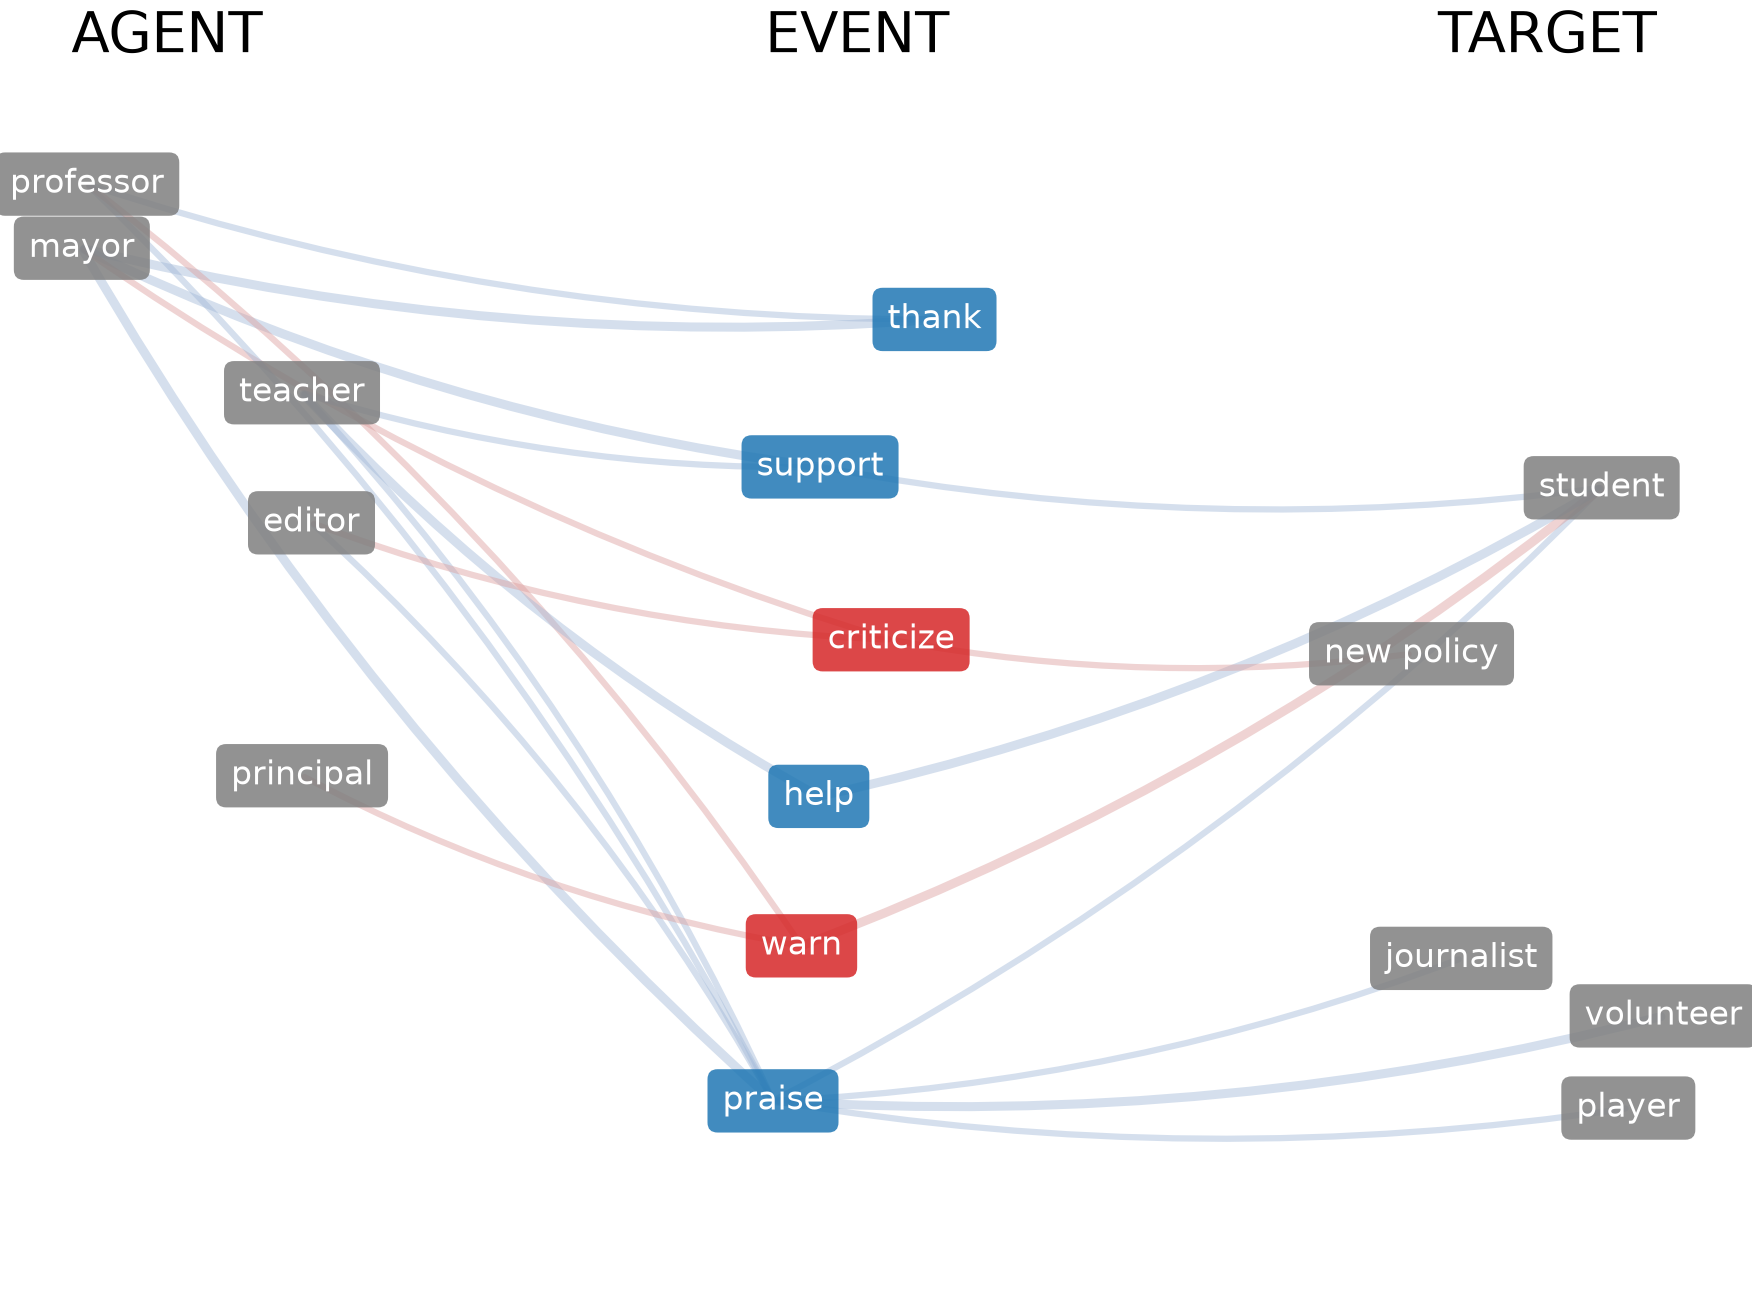

In [9]:
TOP_N = 6
top_actors  = actions["actor"].value_counts().head(TOP_N).index
top_verbs   = actions["verb"].value_counts().head(TOP_N).index
top_objects = actions["object"].dropna().value_counts().head(TOP_N).index

# Actor -> Verb edges (both endpoints among the Top-N)
df_av = actions[actions["actor"].isin(top_actors) & actions["verb"].isin(top_verbs)].copy()
df_av["Node 1"], df_av["TEA"]  = df_av["actor"], "Agent"
df_av["Node 2"], df_av["TEA2"] = df_av["verb"],  "Event"

# Verb -> Object edges (both endpoints among the Top-N)
df_vo = actions[actions["verb"].isin(top_verbs) & actions["object"].isin(top_objects)].copy()
df_vo["Node 1"], df_vo["TEA"]  = df_vo["verb"],   "Event"
df_vo["Node 2"], df_vo["TEA2"] = df_vo["object"], "Target"

graph_df = pd.concat([df_av, df_vo], ignore_index=True)
print(f"{len(graph_df)} edges among the Top-{TOP_N} nodes")
tea.plot_svo_graph(graph_df, custom_font=24, mark_passive_approx=True)

## 8. Active vs passive voice

Passive voice ("the volunteers **were praised by** the mayor") shifts focus from the actor to the target. Comparing voice across actor categories can reveal *who* tends to be foregrounded as an agent.

In [10]:
active  = actions[actions["voice"] == "Active"]
passive = actions[actions["voice"] == "Passive"]
print(f"Active : {len(active):>3} ({100 * len(active) / len(actions):.0f}%)")
print(f"Passive: {len(passive):>3} ({100 * len(passive) / len(actions):.0f}%)")

print("\nCategory x Voice:")
display(actions.groupby(["category", "voice"]).size().unstack(fill_value=0))

Active :  21 (88%)
Passive:   3 (12%)

Category x Voice:


voice,Active,Passive
category,,
Authority / Leadership,9,2
Community,1,0
Education,6,1
Healthcare,1,0
Media,4,0


## 9. (Optional) Corpus-level centrality

The analytics in [Analyzing TEA](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Analyzing%20TEA.ipynb) work on corpus output too. `tea.drop_approximated_svos` removes whole fallback-agent triples (it relies on the unique `svo_id` that batch extraction guarantees), and `tea_weighted_degree_centrality` ranks the most central actors.

In [11]:
clean = tea.drop_approximated_svos(svo)
print(f"drop_approximated_svos: {len(svo)} -> {len(clean)} rows")
tea.tea_weighted_degree_centrality(clean, "Agent").head(8)

drop_approximated_svos: 70 -> 67 rows


,node,degree_centrality
0,mayor,0.129630
1,teacher,0.074074
2,professor,0.055556
3,director,0.037037
4,reporter,0.037037
5,editor,0.037037
6,who,0.018519
7,principal,0.018519


## Next steps

- **Use your own data**: replace `demo_corpus.csv` with a CSV of your documents (one per row, `text` column), or point `--input` at it. Use `--group-col` to split into two groups (e.g. posts vs comments) and `--sample-size` to subsample large corpora.
- **Scale up with GPU**: set `USE_GPU = True` (or pass `--gpu`) on a CUDA machine / Colab GPU runtime.
- **Go deeper**: network metrics in [Analyzing TEA](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Analyzing%20TEA.ipynb); richer actor grouping in [Actor Categorization](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Actor_Categorization_Tutorial.ipynb).